In [ ]:
import imfusion as imf
from imfusion import vision

import numpy as np
import matplotlib.pyplot as plt
import pathlib


In [2]:
# Load left image and attach camera calibration information.
left_image_path = pathlib.Path("data/stereo_left.png")
left_image = imf.load(str(left_image_path))[0]

left_image_calib = vision.CameraCalibrationDataComponent()
left_fx = 1625.408; left_fy = 1625.408; left_cx = 199.345; left_cy = 240.165
left_image_calib.intrinsic_matrix = np.array([
    [left_fx, 0, left_cx],
    [0, left_fy, left_cy],
    [0, 0, 1]
])
left_image_calib.distortion = np.array([0.0]*5) # k1, k2, p1, p2, k3
left_image_calib.image_size = np.array([left_image[0].width, left_image[0].height])
added_component = left_image.components.add(left_image_calib)

# Now do the same for right image
right_image_path = pathlib.Path("data/stereo_right.png")
right_image = imf.load(str(right_image_path))[0]

right_image_calib = vision.CameraCalibrationDataComponent()
right_fx = 1625.408; right_fy = 1625.408; right_cx = 284.364; right_cy = 240.165
right_image_calib.intrinsic_matrix = np.array([
    [right_fx, 0, right_cx],
    [0, right_fy, right_cy],
    [0, 0, 1]
])
right_image_calib.distortion = np.array([0.0]*5) # k1, k2, p1, p2, k3
right_image_calib.image_size = np.array([right_image[0].width, right_image[0].height])
# Also add information of right camera pose w.r.t. the left camera. 
right_image_calib.registration = np.array([
    [1, 0, 0, 169.84],  
    [0, 1, 0, 0],  
    [0, 0, 1, 0],  
    [0, 0, 0, 1]])

added_component = right_image.components.add(right_image_calib)

# Here shows how to create a stereo image set
stereo_img_set = vision.stereo.StereoSharedImageSet(left_image, right_image)


Rectification results:


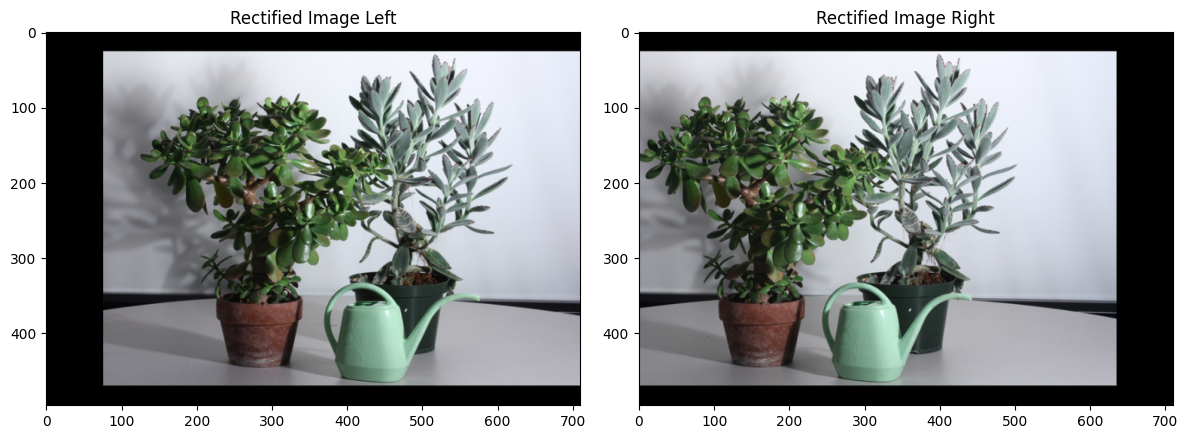

In [3]:
result = vision.stereo.rectify(stereo_img_set, 1, 0)

print(f"\nRectification results:")
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow((result.left)[0], cmap='viridis')
axes[0].set_title('Rectified Image Left')
axes[1].imshow((result.right)[0], cmap='viridis')
axes[1].set_title('Rectified Image Right')
plt.tight_layout()
plt.show()